#   E. coli coding analysis template

##  Description

This notebook is a codon analysis of the *E. coli* genome. It reuses the RefSeq loading workflow and binary-signal construction logic from the EDA notebook.

In [1]:
import io
import math
from enum import Enum

import numpy as np
import pandas as pd
import pywt
from Bio import Entrez, SeqIO
import Bio

ACCESSION = "NC_000913.3"  # E. coli K-12 MG1655 complete genome
EMAIL = "daniel_mcgonigle1@student.uml.edu"  # NCBI asks for an email

Entrez.email = EMAIL


In [2]:
def fetch_genbank_record(accession: str) -> Bio.SeqRecord.SeqRecord:
    """
    Fetch a nucleotide sequence record from NCBI and parse it into a Biopython SeqRecord.

    Parameters
    ----------
    accession : str
        RefSeq or GenBank accession for the genome of interest.

    Returns
    -------
    Bio.SeqRecord.SeqRecord
        Parsed record containing the DNA sequence and feature annotations.
    """
    with Entrez.efetch(db="nuccore", id=accession, rettype="gbwithparts", retmode="text") as handle:
        text = handle.read()
    return SeqIO.read(io.StringIO(text), "genbank")


class SignalType(str, Enum):
    """Signal domain choices for genome-derived indicator signals."""

    FULL = "full"
    CDS = "cds"
    NONCDS = "noncds"


record = fetch_genbank_record(ACCESSION)
sequence = str(record.seq).upper()
genome_len = len(sequence)

print(f"Record ID: {record.id}")
print(f"Description: {record.description}")
print(f"Genome length: {genome_len:,} bp")
print(f"Annotated feature types: {sorted({feat.type for feat in record.features})}")


Record ID: NC_000913.3
Description: Escherichia coli str. K-12 substr. MG1655, complete genome
Genome length: 4,641,652 bp
Annotated feature types: ['CDS', 'gene', 'misc_feature', 'mobile_element', 'ncRNA', 'rRNA', 'rep_origin', 'source', 'tRNA']


In [3]:
def build_cds_mask(record: Bio.SeqRecord.SeqRecord, sequence_length: int) -> np.ndarray:
    """
    Build a boolean mask marking every base position covered by a CDS annotation.

    Parameters
    ----------
    record : Bio.SeqRecord.SeqRecord
        Record whose CDS annotations define coding positions.
    sequence_length : int
        Length of the full genome sequence.

    Returns
    -------
    np.ndarray
        Boolean mask whose True entries indicate genome positions covered by at
        least one CDS interval.
    """
    cds_mask = np.zeros(sequence_length, dtype=bool)
    for feat in record.features:
        if feat.type != "CDS":
            continue

        parts = getattr(feat.location, "parts", [feat.location])
        for part in parts:
            start = int(part.start)
            end = int(part.end)
            cds_mask[start:end] = True

    return cds_mask


def extract_signal_sequence(
    sequence: str,
    record: Bio.SeqRecord.SeqRecord,
    signal_type: SignalType,
) -> str:
    """
    Extract the sequence corresponding to a requested signal domain.

    Parameters
    ----------
    sequence : str
        Full nucleotide sequence.
    record : Bio.SeqRecord.SeqRecord
        Record whose CDS annotations define coding and non-coding positions.
    signal_type : SignalType
        Which sequence domain to extract: full genome, CDS-only, or the
        complement of CDS.

    Returns
    -------
    str
        Sequence associated with the selected signal type.

    Notes
    -----
    SignalType.CDS is built by concatenating CDS feature intervals in record order.
    SignalType.NONCDS is built as the complement of the CDS mask across the full genome,
    so it cannot exceed the full-genome length.
    """
    if signal_type == SignalType.FULL:
        return sequence

    cds_mask = build_cds_mask(record, len(sequence))

    if signal_type == SignalType.CDS:
        return "".join(np.asarray(list(sequence))[cds_mask])
    if signal_type == SignalType.NONCDS:
        return "".join(np.asarray(list(sequence))[~cds_mask])

    raise ValueError(f"Unsupported signal_type: {signal_type}")


def create_binary_signal(
    bases: str,
    sequence: str,
    record: Bio.SeqRecord.SeqRecord,
    signal_type: SignalType = SignalType.FULL,
) -> np.ndarray:
    """
    Create a binary nucleotide indicator signal.

    Parameters
    ----------
    bases : str
        One or more nucleotide letters to mark with 1s, for example "GC" or "A".
    sequence : str
        Full sequence from which the signal is built.
    record : Bio.SeqRecord.SeqRecord
        Record whose CDS annotations determine the selected signal domain.
    signal_type : SignalType, default SignalType.FULL
        Which domain to encode: full genome, CDS-only, or non-CDS as the
        complement of CDS.

    Returns
    -------
    np.ndarray
        One-dimensional int8 array of 0s and 1s.
    """
    selected_bases = {base.upper() for base in bases if not base.isspace()}
    if not selected_bases:
        raise ValueError("bases must contain at least one nucleotide letter")

    sequence_to_encode = extract_signal_sequence(sequence, record, signal_type)

    return np.fromiter(
        (1 if base in selected_bases else 0 for base in sequence_to_encode),
        dtype=np.int8,
    )


## Codon-level analyses

The cells below add a strand-aware CDS extraction workflow and then compute:

1. Base composition by codon position (position 1 vs 2 vs 3 across all annotated CDS)
2. Codon triplet frequencies / histogram

These analyses operate on annotated CDS features .


In [5]:
import matplotlib.pyplot as plt
from collections import Counter
from Bio.Data import CodonTable

BACTERIAL_CODE_ID = 11
bacterial_table = CodonTable.unambiguous_dna_by_id[BACTERIAL_CODE_ID]


def extract_cds_sequences(record: Bio.SeqRecord.SeqRecord):
    """Extract CDS nucleotide sequences in translation frame, respecting strand."""
    cds_entries = []
    for idx, feat in enumerate(record.features):
        if feat.type != "CDS":
            continue
        raw_seq = str(feat.extract(record.seq)).upper()
        codon_start = int(feat.qualifiers.get("codon_start", ["1"])[0])
        transl_table = int(feat.qualifiers.get("transl_table", [str(BACTERIAL_CODE_ID)])[0])
        locus_tag = feat.qualifiers.get("locus_tag", [f"cds_{idx}"])[0]
        gene = feat.qualifiers.get("gene", [locus_tag])[0]
        product = feat.qualifiers.get("product", [""])[0]
        in_frame_seq = raw_seq[codon_start - 1 :]
        trimmed_len = len(in_frame_seq) - (len(in_frame_seq) % 3)
        in_frame_seq = in_frame_seq[:trimmed_len]
        cds_entries.append({
            "gene": gene,
            "locus_tag": locus_tag,
            "product": product,
            "transl_table": transl_table,
            "sequence": in_frame_seq,
            "codon_count": len(in_frame_seq) // 3,
        })
    return cds_entries


def count_codon_positions(cds_entries):
    """Count A/C/G/T prevalence separately at codon positions 1, 2, and 3."""
    counts = {1: Counter(), 2: Counter(), 3: Counter()}
    for entry in cds_entries:
        seq = entry["sequence"]
        for i in range(0, len(seq), 3):
            codon = seq[i : i + 3]
            if len(codon) != 3 or any(base not in "ACGT" for base in codon):
                continue
            for pos, base in enumerate(codon, start=1):
                counts[pos][base] += 1
    rows = []
    for pos in [1, 2, 3]:
        total = sum(counts[pos].values())
        row = {"position": pos, "total_codons": total}
        for base in "ACGT":
            row[f"{base}_count"] = counts[pos][base]
            row[f"{base}_fraction"] = counts[pos][base] / total if total else np.nan
        row["GC_fraction"] = (counts[pos]["G"] + counts[pos]["C"]) / total if total else np.nan
        row["GA_ratio"] = counts[pos]["G"] / counts[pos]["A"] if counts[pos]["A"] else np.nan
        rows.append(row)
    return pd.DataFrame(rows)


def build_codon_usage_df(cds_entries, genetic_code_id=BACTERIAL_CODE_ID):
    """Count codon frequencies across all CDS and annotate each codon with amino acid information."""
    table = CodonTable.unambiguous_dna_by_id[genetic_code_id]
    codon_counts = Counter()
    for entry in cds_entries:
        seq = entry["sequence"]
        for i in range(0, len(seq), 3):
            codon = seq[i : i + 3]
            if len(codon) == 3 and all(base in "ACGT" for base in codon):
                codon_counts[codon] += 1
    all_codons = sorted([a + b + c for a in "TCAG" for b in "TCAG" for c in "TCAG"])
    rows = []
    total = sum(codon_counts.values())
    for codon in all_codons:
        aa = table.forward_table.get(codon, "Stop")
        rows.append({
            "codon": codon,
            "count": codon_counts[codon],
            "fraction": codon_counts[codon] / total if total else np.nan,
            "amino_acid": aa,
            "third_base": codon[2],
            "is_stop": codon in table.stop_codons,
            "gc_count": sum(base in "GC" for base in codon),
        })
    return pd.DataFrame(rows).sort_values(["count", "codon"], ascending=[False, True]).reset_index(drop=True)


def build_amino_acid_usage_df(codon_df):
    aa_df = codon_df.groupby("amino_acid", dropna=False, as_index=False)["count"].sum()
    aa_df = aa_df.sort_values("count", ascending=False).reset_index(drop=True)
    total = aa_df["count"].sum()
    aa_df["fraction"] = aa_df["count"] / total if total else np.nan
    return aa_df


def build_third_position_summary(codon_df):
    third = codon_df.groupby("third_base", as_index=False)["count"].sum().sort_values("third_base")
    total = third["count"].sum()
    third["fraction"] = third["count"] / total if total else np.nan
    return third


def compute_rscu(codon_df):
    """Relative synonymous codon usage; stop codons excluded."""
    non_stop = codon_df.loc[~codon_df["is_stop"]].copy()
    synonym_sizes = non_stop.groupby("amino_acid")["codon"].transform("count")
    amino_totals = non_stop.groupby("amino_acid")["count"].transform("sum")
    expected = amino_totals / synonym_sizes
    non_stop["rscu"] = np.where(expected > 0, non_stop["count"] / expected, np.nan)
    return non_stop.sort_values(["amino_acid", "rscu"], ascending=[True, False]).reset_index(drop=True)


In [6]:
cds_entries = extract_cds_sequences(record)
position_df = count_codon_positions(cds_entries)
codon_df = build_codon_usage_df(cds_entries)
aa_df = build_amino_acid_usage_df(codon_df)
third_base_df = build_third_position_summary(codon_df)
rscu_df = compute_rscu(codon_df)

print(f"Annotated CDS entries analyzed: {len(cds_entries):,}")
print(f"Total in-frame codons counted: {int(position_df['total_codons'].iloc[0]):,}")
position_df


Annotated CDS entries analyzed: 4,318
Total in-frame codons counted: 1,342,295


,position,total_codons,A_count,A_fraction,C_count,C_fraction,G_count,G_fraction,T_count,T_fraction,GC_fraction,GA_ratio
0,1,1342295,338689,0.252321,325001,0.242123,467220,0.348075,211385,0.157480,0.590199,1.379496
1,2,1342295,388194,0.289202,303138,0.225836,242897,0.180956,408066,0.304006,0.406792,0.625710
2,3,1342295,242041,0.180319,360615,0.268656,391020,0.291307,348619,0.259719,0.559963,1.615511


### Interpretation guide for the codon-position table

- Position 1 / 2 / 3 refer to the first, second, and third base of each annotated codon.

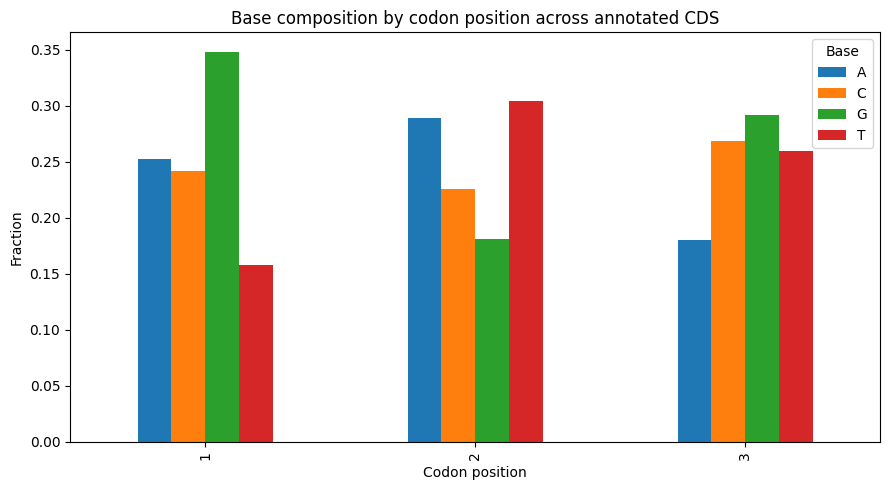

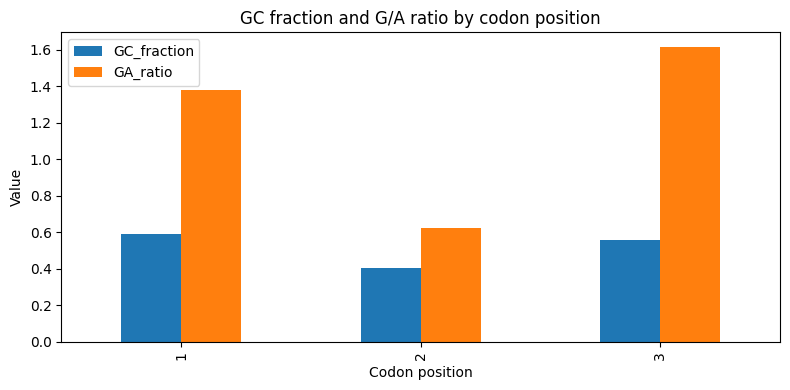

In [7]:
plot_df = position_df.set_index("position")[[f"{base}_fraction" for base in "ACGT"]]
ax = plot_df.plot(kind="bar", figsize=(9, 5))
ax.set_xlabel("Codon position")
ax.set_ylabel("Fraction")
ax.set_title("Base composition by codon position across annotated CDS")
ax.legend(title="Base", labels=list("ACGT"))
plt.tight_layout()
plt.show()

summary_plot_df = position_df.set_index("position")[["GC_fraction", "GA_ratio"]]
ax = summary_plot_df.plot(kind="bar", figsize=(8, 4))
ax.set_xlabel("Codon position")
ax.set_ylabel("Value")
ax.set_title("GC fraction and G/A ratio by codon position")
plt.tight_layout()
plt.show()


### Codon triplet prevalence

The next cells count each codon triplet across all annotated coding sequences, display the most frequent codons, and then plot a histogram-style bar chart over all 64 possible codons.


In [8]:
codon_df.head(20)


,codon,count,fraction,amino_acid,third_base,is_stop,gc_count
0,CTG,71314,0.053128,L,G,False,2
1,GAA,53330,0.039730,E,A,False,1
2,GCG,45521,0.033913,A,G,False,3
3,AAA,45204,0.033677,K,A,False,0
4,GAT,43048,0.032070,D,T,False,1
5,ATT,40914,0.030481,I,T,False,0
6,GGC,40020,0.029815,G,C,False,3
7,CAG,38840,0.028936,Q,G,False,2
8,ATG,37401,0.027863,M,G,False,1
9,GTG,35338,0.026327,V,G,False,2


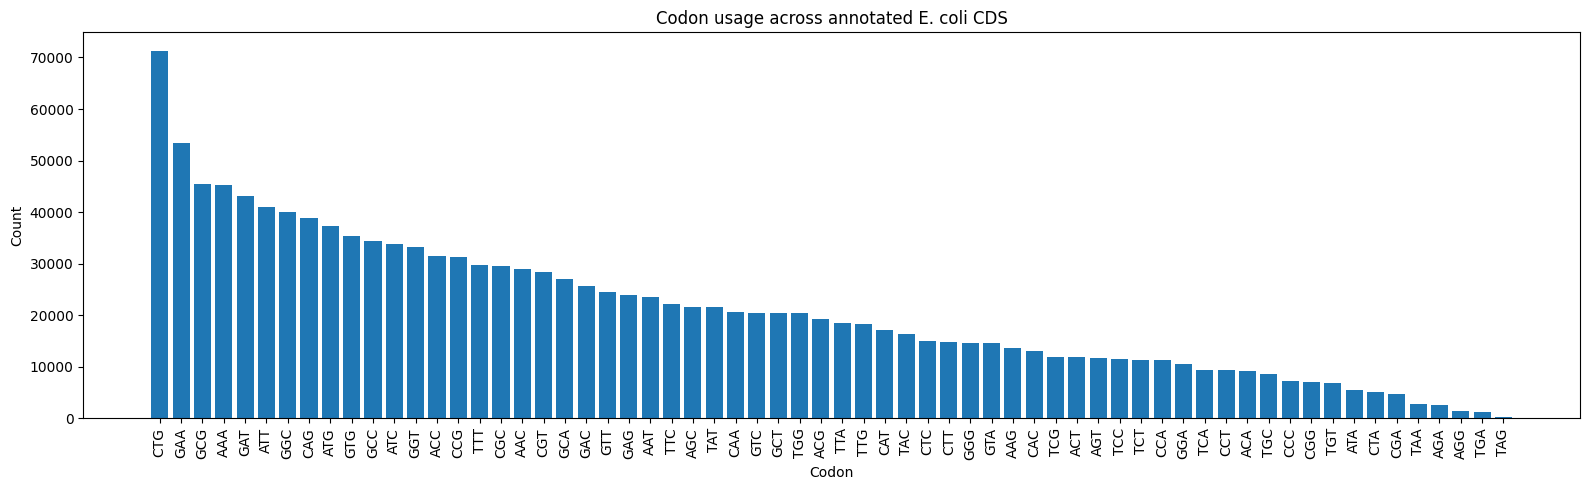

In [9]:
plt.figure(figsize=(16, 5))
plt.bar(codon_df["codon"], codon_df["count"])
plt.xticks(rotation=90)
plt.xlabel("Codon")
plt.ylabel("Count")
plt.title("Codon usage across annotated E. coli CDS")
plt.tight_layout()
plt.show()


# Codon to amino acid breakdown

The table below is derived from [NCBI](https://www.ncbi.nlm.nih.gov/Taxonomy/Utils/wprintgc.cgi#SG11).

- Phenylalanine (F): TTC, TTT
- Leucine (L): CTA, CTC, CTG, CTT, TTA, TTG
- Isoleucine (I): ATA, ATC, ATT
- Methionine (M): ATG
- Valine (V): GTA, GTC, GTG, GTT
- Serine (S): AGC, AGT, TCA, TCC, TCG, TCT
- Proline (P): CCA, CCC, CCG, CCT
- Threonine (T): ACA, ACC, ACG, ACT
- Alanine (A): GCA, GCC, GCG, GCT
- Tyrosine (Y): TAC, TAT
- Histidine (H): CAC, CAT
- Glutamine (Q): CAA, CAG
- Asparagine (N): AAC, AAT
- Lysine (K): AAA, AAG
- Aspartic acid (D): GAC, GAT
- Glutamic acid (E): GAA, GAG
- Cysteine (C): TGC, TGT
- Tryptophan (W): TGG
- Arginine (R): AGA, AGG, CGA, CGC, CGG, CGT
- Glycine (G): GGA, GGC, GGG, GGT
- Stop (Stop): TAA, TAG, TGA


### Amino acid frequencies inferred from codon usage

This is the genome-wide amino acid composition implied by the annotated coding sequences, counting codons directly from the DNA.


In [10]:
aa_df


,amino_acid,count,fraction
0,L,143023,0.106551
1,A,127516,0.094998
2,G,98565,0.073430
3,V,95137,0.070876
4,I,80417,0.059910
5,S,77531,0.057760
6,E,77227,0.057534
7,R,73905,0.055059
8,T,72072,0.053693
9,D,68775,0.051237


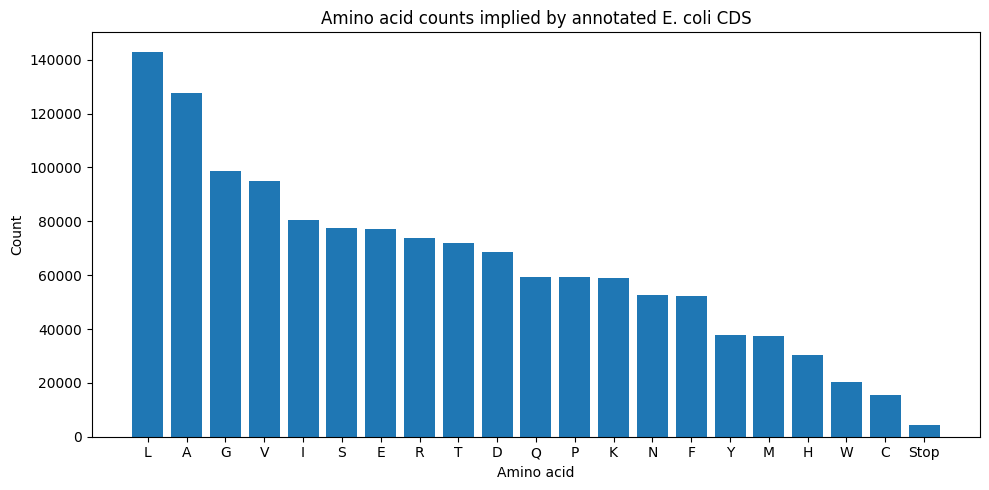

In [11]:
plt.figure(figsize=(10, 5))
plt.bar(aa_df["amino_acid"].astype(str), aa_df["count"])
plt.xlabel("Amino acid")
plt.ylabel("Count")
plt.title("Amino acid counts implied by annotated E. coli CDS")
plt.tight_layout()
plt.show()


### Extra summaries relevant to the G-vs-A question

These help narrow down *why* coding sequence can show **G > A** even when the full genome difference is modest.

1. **Third-position base composition**: if synonymous codon choice is important, this is where the strongest signal should appear.
2. **RSCU (relative synonymous codon usage)**: shows which synonymous codons are favored beyond what you would expect under equal usage.
3. **GC count per codon**: a coarse summary of how GC-rich the observed codons are.


In [13]:
print("Third-base composition across observed codons:")
display(third_base_df)

print("Top synonymous-codon preferences by RSCU:")
display(rscu_df.head(30))

print("Distribution of codons by number of G/C bases:")
gc_per_codon_df = codon_df.groupby("gc_count", as_index=False)["count"].sum().sort_values("gc_count")
gc_per_codon_df["fraction"] = gc_per_codon_df["count"] / gc_per_codon_df["count"].sum()
display(gc_per_codon_df)


Third-base composition across observed codons:


,third_base,count,fraction
0,A,242041,0.180319
1,C,360615,0.268656
2,G,391020,0.291307
3,T,348619,0.259719


Top synonymous-codon preferences by RSCU:


,codon,count,fraction,amino_acid,third_base,is_stop,gc_count,rscu
0,GCG,45521,0.033913,A,G,False,3,1.427931
1,GCC,34433,0.025652,A,C,False,3,1.080115
2,GCA,27072,0.020168,A,A,False,2,0.849211
3,GCT,20490,0.015265,A,T,False,2,0.642743
4,TGC,8661,0.006452,C,C,False,2,1.115318
5,TGT,6870,0.005118,C,T,False,1,0.884682
6,GAT,43048,0.032070,D,T,False,1,1.251850
7,GAC,25727,0.019166,D,C,False,2,0.748150
8,GAA,53330,0.039730,E,A,False,1,1.381123
9,GAG,23897,0.017803,E,G,False,2,0.618877


Distribution of codons by number of G/C bases:


,gc_count,count,fraction
0,0,187844,0.139942
1,1,429152,0.319715
2,2,515158,0.383789
3,3,210141,0.156554


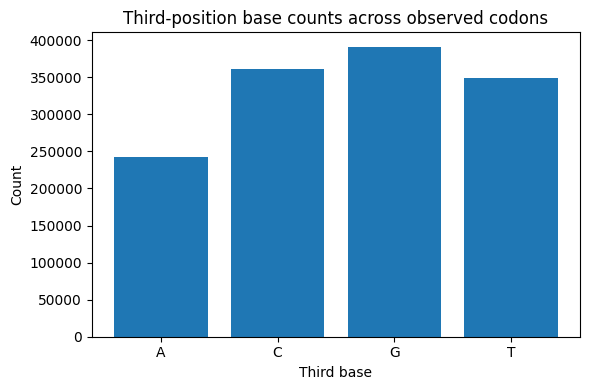

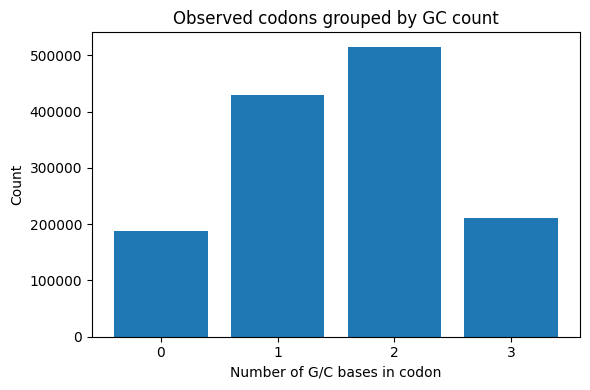

In [14]:
plt.figure(figsize=(6, 4))
plt.bar(third_base_df["third_base"], third_base_df["count"])
plt.xlabel("Third base")
plt.ylabel("Count")
plt.title("Third-position base counts across observed codons")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(gc_per_codon_df["gc_count"].astype(str), gc_per_codon_df["count"])
plt.xlabel("Number of G/C bases in codon")
plt.ylabel("Count")
plt.title("Observed codons grouped by GC count")
plt.tight_layout()
plt.show()
